# **1. Entendimiento del Negocio**

La unidad de psicología de un hospital universitario quiere entender los patrones y efectos sobre el uso de SmartPhones entre los jóvenes, haciendo un enfoque especial en entender niveles de adicción al uso de este tipo de dispositivos. La intención es entonces conocer cuáles pueden ser los efectos en cuanto a la posibilidad de desarrollar niveles de adicción.

# **2. Enfoque Analítico**

Desarrollar un experimento de clasificación que permita determinar los niveles de adicción de jóvenes con un nivel de desempeño superior al 85%

# **3. Requerimiento de Datos**

- Datos comportamentales
- Datos demográficos
- Datos de hábitos
- Nivel de adicción

# **4. Recolección de los Datos**

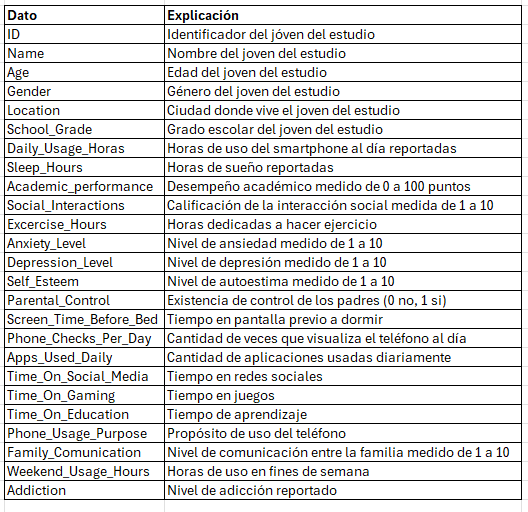

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

##Importación de los datos
data = pd.read_csv('data_clf.csv')
data

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78.0,5.0,...,1.4,86,19.0,3.6,1.7,1.2,Browsing,4.0,8.7,High
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70.0,5.0,...,0.9,96,9.0,1.1,4.0,1.8,Browsing,2.0,5.3,High
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93.0,8.0,...,0.5,137,8.0,0.3,1.5,0.4,Education,6.0,5.7,High
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78.0,8.0,...,1.4,128,7.0,3.1,1.6,0.8,Social Media,8.0,3.0,High
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56.0,4.0,...,1.0,96,20.0,2.6,0.9,1.1,Gaming,10.0,3.7,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53.0,4.0,...,0.3,80,15.0,2.7,1.8,1.0,NaN,8.0,9.4,High
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93.0,5.0,...,0.9,45,8.0,3.1,0.0,0.3,Gaming,9.0,5.2,Medium
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98.0,1.0,...,0.2,51,13.0,2.4,0.2,2.4,Social Media,9.0,5.9,Medium
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67.0,3.0,...,1.6,125,17.0,1.7,2.6,1.5,Browsing,4.0,6.1,High


# **5. Entendimiento de los datos**

- Datos nulos
- Estadísticas univariada, bivariada y multivariada
- Desbalance de y

In [2]:
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
#Identificación de datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       2900 non-null   float64
 7   Sleep_Hours             2900 non-null   float64
 8   Academic_Performance    2900 non-null   float64
 9   Social_Interactions     2900 non-null   float64
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           2900 non-null   float64
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        2900 non-null   

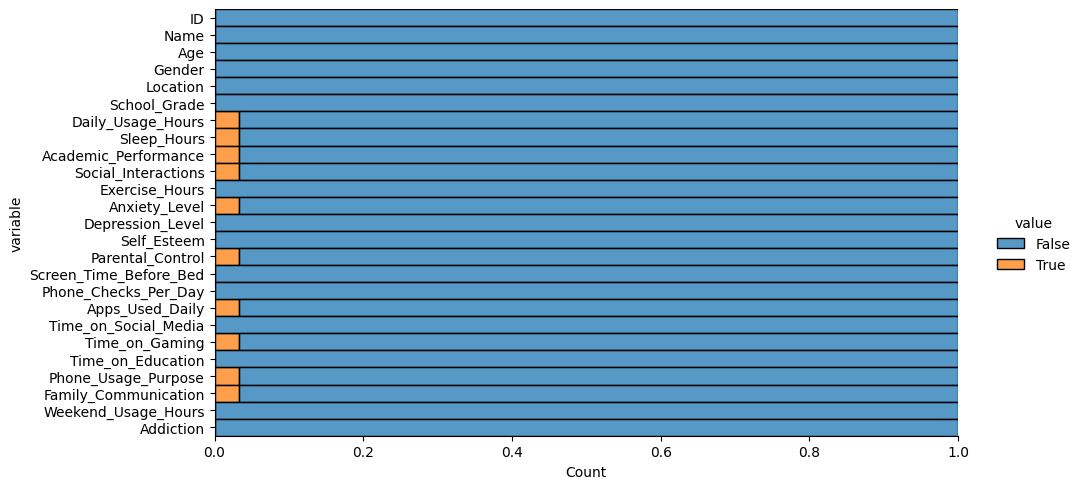

In [4]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

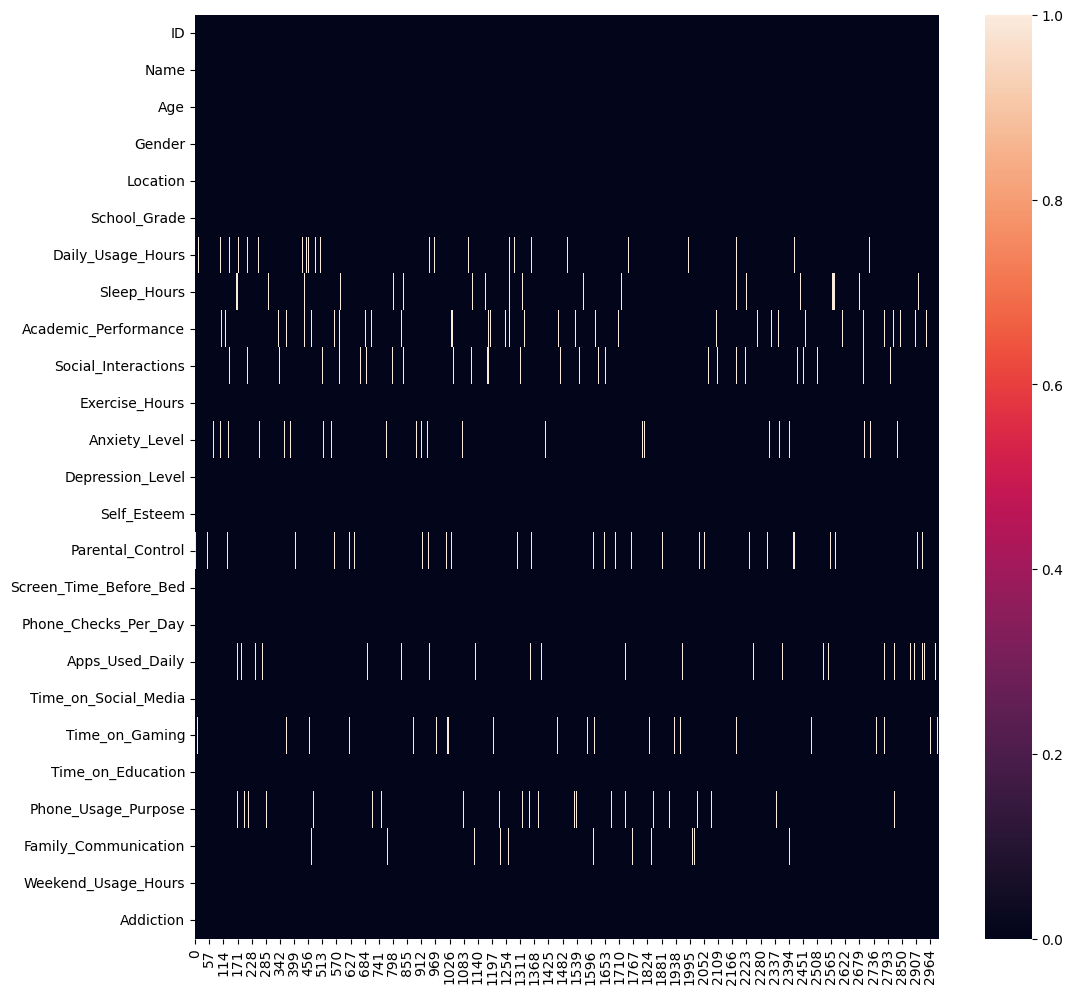

In [5]:
plt.figure(figsize = (12, 12))
data.isnull().transpose().pipe(lambda df: sb.heatmap(data = df))
plt.show()

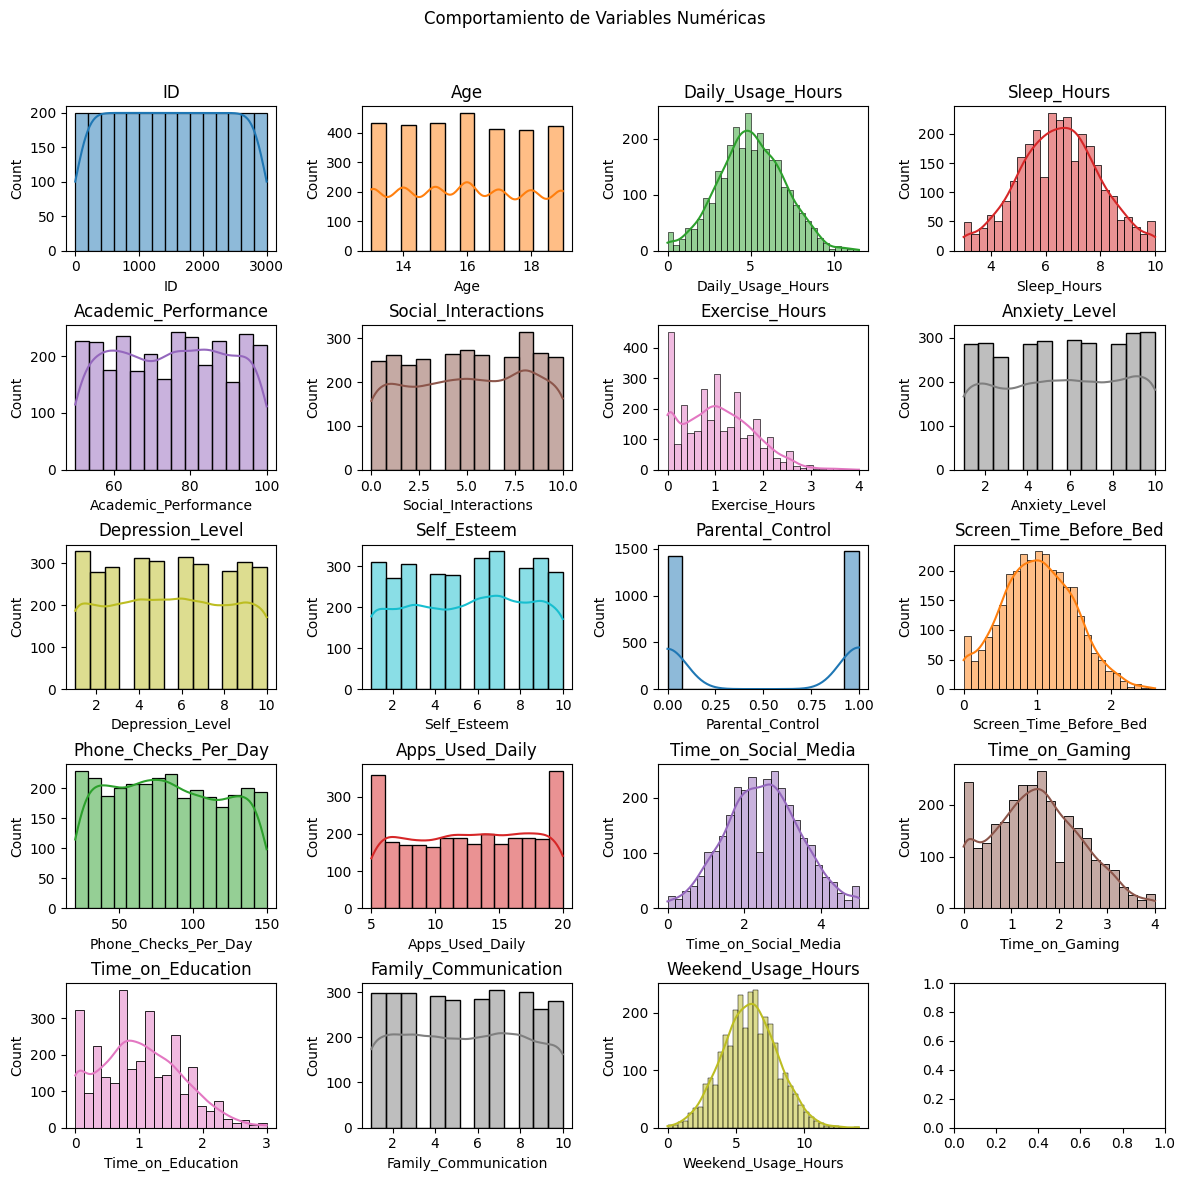

In [6]:
#Exploración univariada de los datos
##Para datos numéricos: histogramas de frecuencia
##Para datos categóricos: gráficos de torta

###HISTOGRAMAS DE FRECUENCIA
fig, ax = plt.subplots(5, 4, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, 
                kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

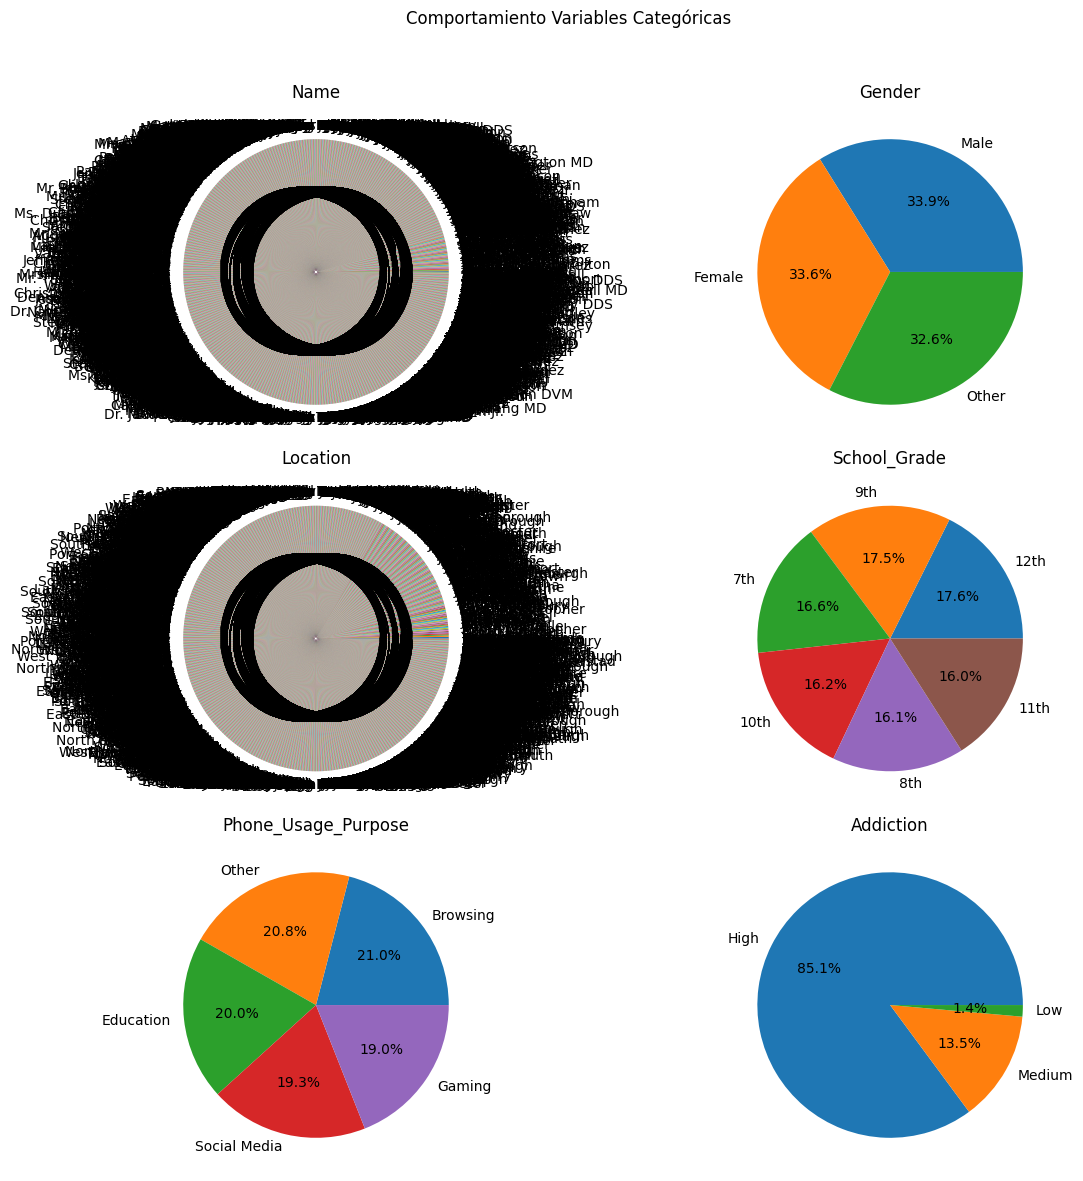

In [7]:
##GRÁFICOS DE TORTA
fig, ax = plt.subplots(3, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

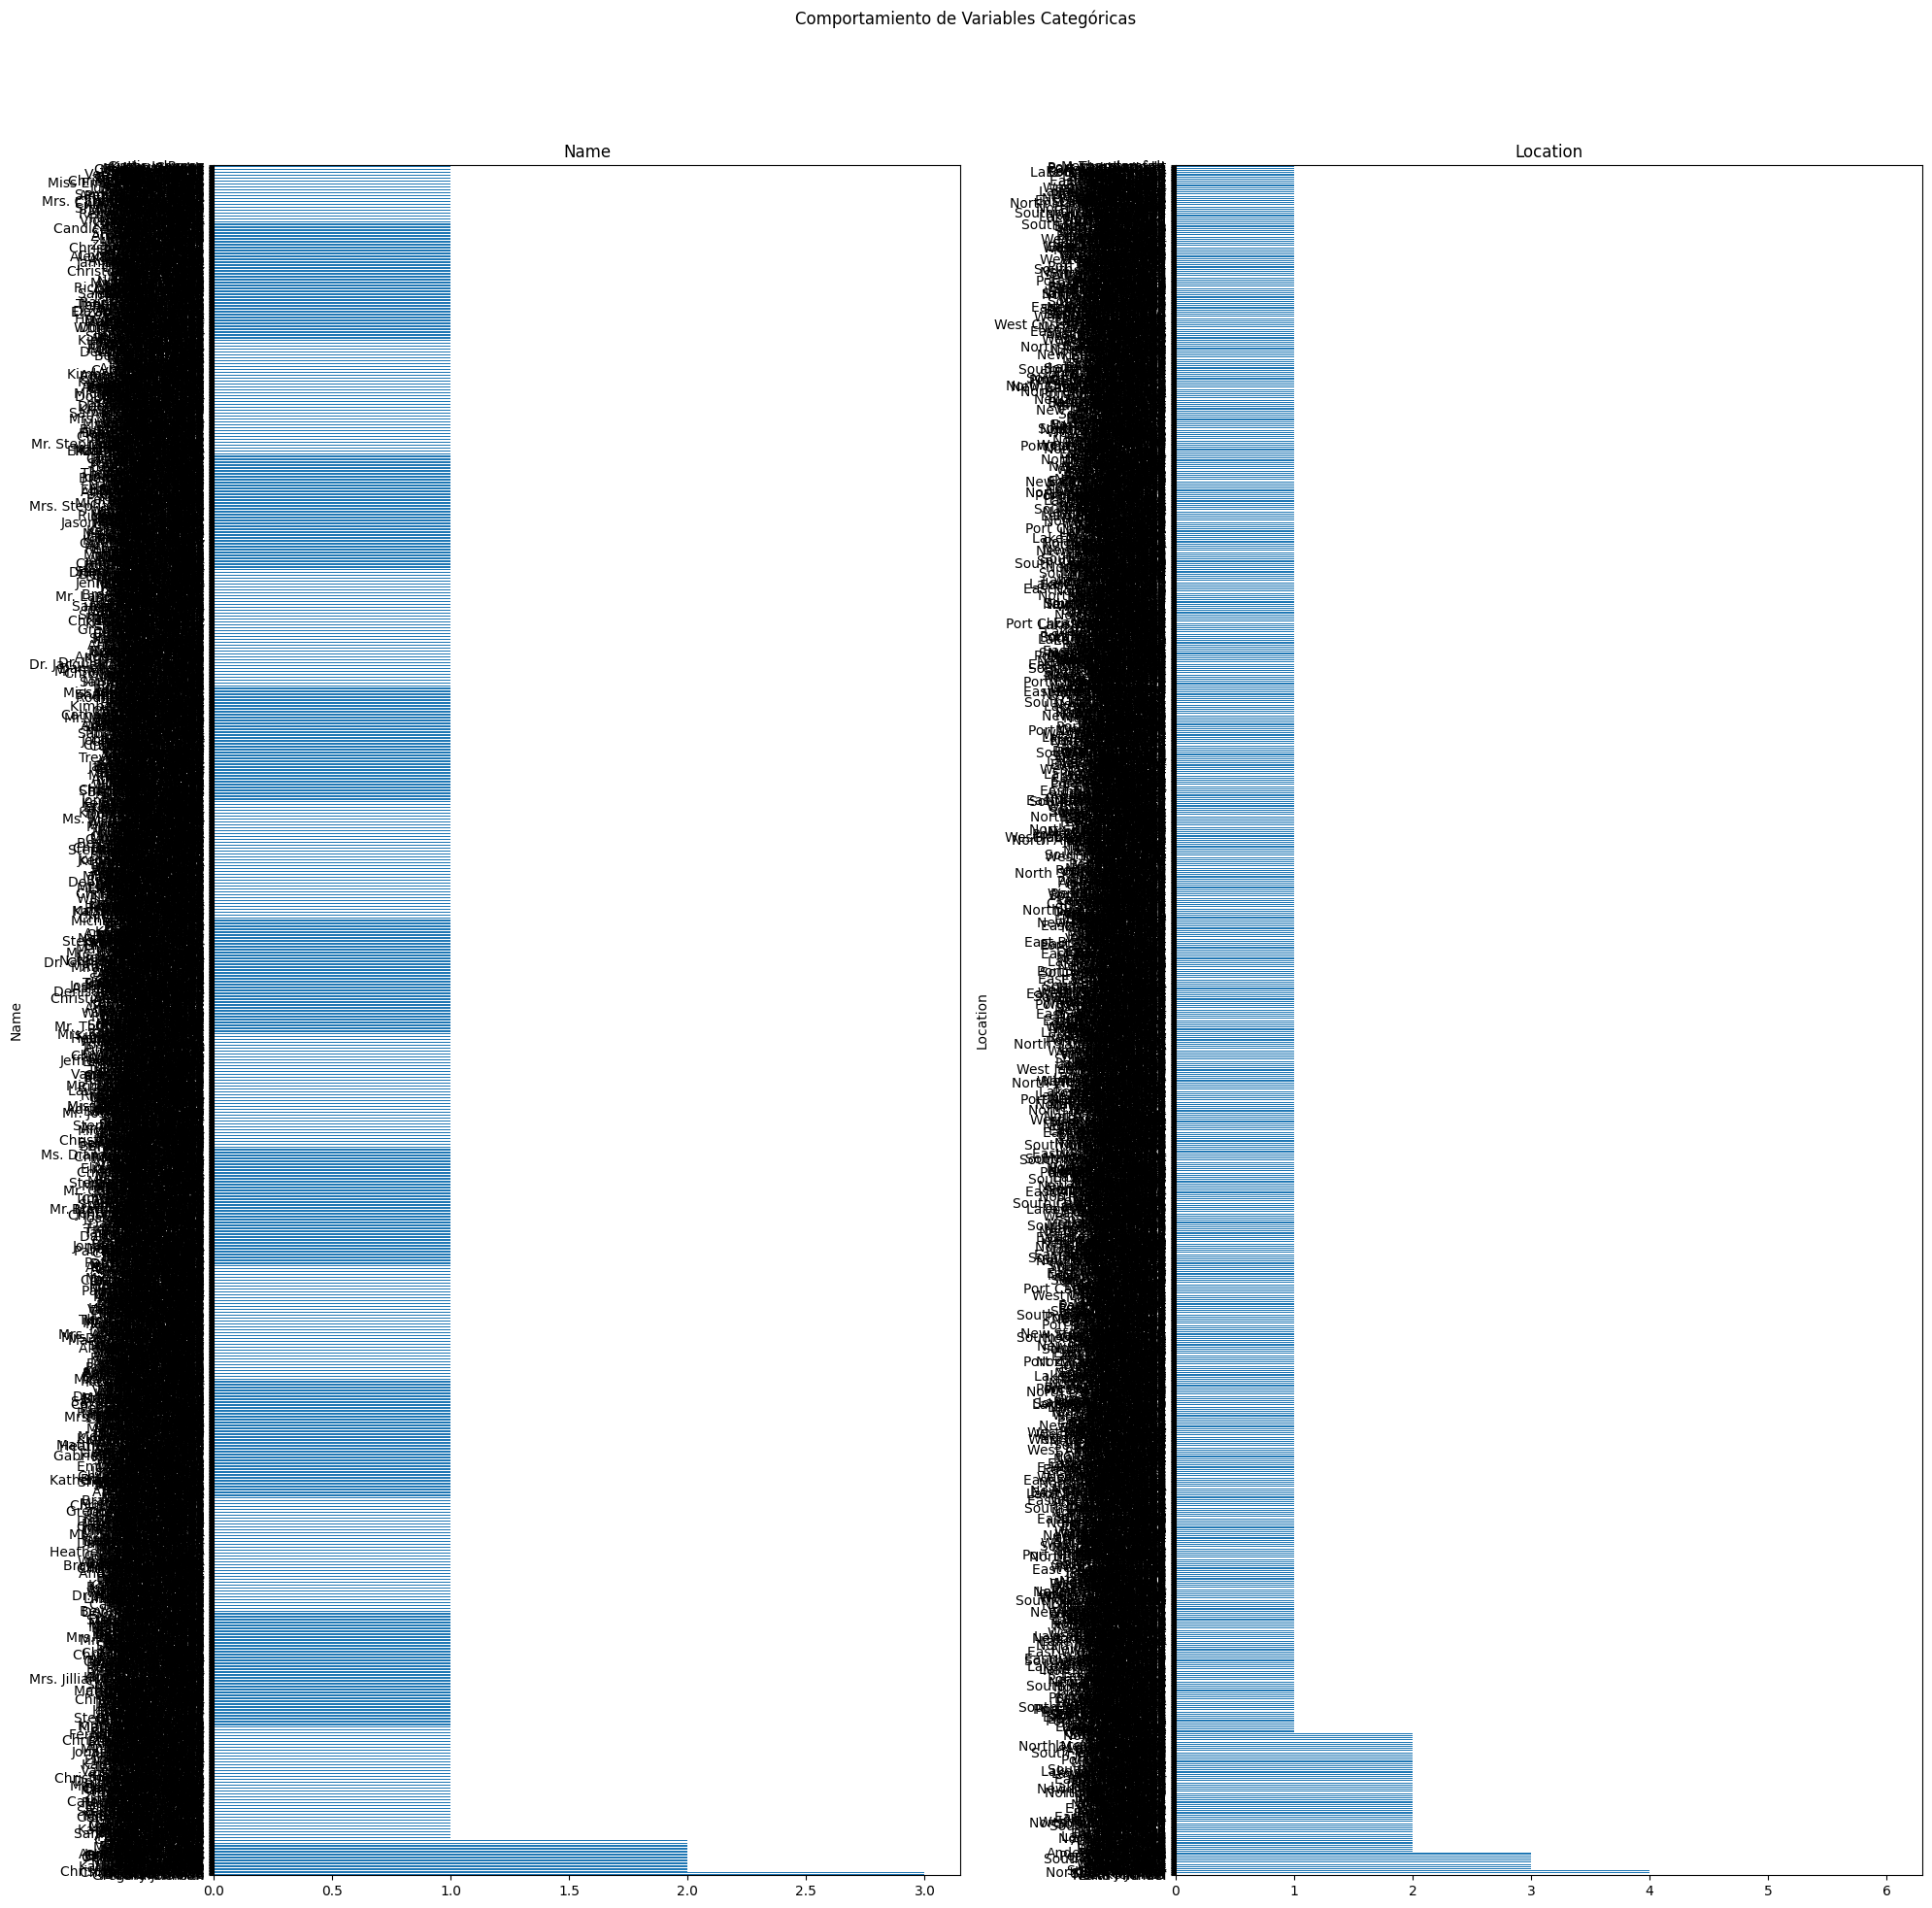

In [8]:
##Gráfico de barras para variables categóricas
fig, ax = plt.subplots(1, 2, figsize = (20, 20))
ax = ax.flat

col = data[['Name', 'Location']]
for i, col in enumerate(col):
    data[col].value_counts().plot.barh(ax = ax[i])
    ax[i].set_title(col)

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Categóricas')
plt.show()

# **6. Preparación de los Datos**

- Eliminar variables que no son significativas
- Completar variables que cuentan con datos nulos
- Separar en conjuntos de entrenamiento y prueba
- Balancear y
- Transformar los datos para que sean usables por el modelo

In [9]:
data.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction'],
      dtype='object')

In [10]:

data_mod = data.drop(['ID', 'Name', 'Location', 'Age'], axis=1)



data_mod.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  3000 non-null   object 
 1   School_Grade            3000 non-null   object 
 2   Daily_Usage_Hours       2900 non-null   float64
 3   Sleep_Hours             2900 non-null   float64
 4   Academic_Performance    2900 non-null   float64
 5   Social_Interactions     2900 non-null   float64
 6   Exercise_Hours          3000 non-null   float64
 7   Anxiety_Level           2900 non-null   float64
 8   Depression_Level        3000 non-null   int64  
 9   Self_Esteem             3000 non-null   int64  
 10  Parental_Control        2900 non-null   float64
 11  Screen_Time_Before_Bed  3000 non-null   float64
 12  Phone_Checks_Per_Day    3000 non-null   int64  
 13  Apps_Used_Daily         2900 non-null   float64
 14  Time_on_Social_Media    3000 non-null   

In [11]:
data_mod.fillna(20).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  3000 non-null   object 
 1   School_Grade            3000 non-null   object 
 2   Daily_Usage_Hours       3000 non-null   float64
 3   Sleep_Hours             3000 non-null   float64
 4   Academic_Performance    3000 non-null   float64
 5   Social_Interactions     3000 non-null   float64
 6   Exercise_Hours          3000 non-null   float64
 7   Anxiety_Level           3000 non-null   float64
 8   Depression_Level        3000 non-null   int64  
 9   Self_Esteem             3000 non-null   int64  
 10  Parental_Control        3000 non-null   float64
 11  Screen_Time_Before_Bed  3000 non-null   float64
 12  Phone_Checks_Per_Day    3000 non-null   int64  
 13  Apps_Used_Daily         3000 non-null   float64
 14  Time_on_Social_Media    3000 non-null   

In [12]:
import sklearn
import sklearn.preprocessing
import sklearn.compose  # Necesario para make_column_transformer

# Seleccionar columnas categóricas
categorical_cols = data_mod.select_dtypes(include='object').columns

# Crear transformador para codificar columnas categóricas
categorical_transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_cols),
    remainder='passthrough'
)


In [13]:
# Ajustar el transformador con los datos originales
categorical_transformer.fit(data_mod)

# Verificar el nombre asignado al encoder
print(categorical_transformer.named_transformers_)


{'ordinalencoder': OrdinalEncoder(), 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                    feature_names_out='one-to-one')}


In [14]:
# Justo después de ajustar categorical_transformer y ANTES de cambiar nombres:
cat_idx = list(range(len(categorical_cols)))  # Las columnas categóricas están al inicio

# Luego creas data_transformed normalmente
data_transformed = pd.DataFrame(
    categorical_transformer.transform(data_mod),
    columns=categorical_transformer.get_feature_names_out(),
    index=data_mod.index
).rename(columns=lambda x: x.removeprefix('ordinalencoder__')).rename(columns=lambda x: x.removeprefix('remainder__'))


In [15]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data_mod),columns = categorical_transformer.get_feature_names_out(),index = data_mod.index).rename(columns=lambda x:x.removeprefix('originalencoder__')).rename(columns=lambda x:x.removeprefix('remainder__'))

In [16]:
knn_imputer = sklearn.impute.KNNImputer(n_neighbors=10)

data_knn_df = pd.DataFrame(knn_imputer.fit_transform(data_transformed).round(),
                          columns = data_transformed.columns,
                          index=data_transformed.index)

data_knn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ordinalencoder__Gender               3000 non-null   float64
 1   ordinalencoder__School_Grade         3000 non-null   float64
 2   ordinalencoder__Phone_Usage_Purpose  3000 non-null   float64
 3   ordinalencoder__Addiction            3000 non-null   float64
 4   Daily_Usage_Hours                    3000 non-null   float64
 5   Sleep_Hours                          3000 non-null   float64
 6   Academic_Performance                 3000 non-null   float64
 7   Social_Interactions                  3000 non-null   float64
 8   Exercise_Hours                       3000 non-null   float64
 9   Anxiety_Level                        3000 non-null   float64
 10  Depression_Level                     3000 non-null   float64
 11  Self_Esteem                   

In [17]:
from sklearn.experimental import enable_iterative_imputer  # 👈 Habilita IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
import pandas as pd

# Crear imputador
recursive_imputer = IterativeImputer(
    estimator=LinearRegression(),
    initial_strategy='mean',
    max_iter=10
)

# Aplicar al DataFrame
data_recursive_df = pd.DataFrame(
    recursive_imputer.fit_transform(data_transformed).round(),
    columns=data_transformed.columns,
    index=data_transformed.index
)

# Ver información del DataFrame resultante
data_recursive_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ordinalencoder__Gender               3000 non-null   float64
 1   ordinalencoder__School_Grade         3000 non-null   float64
 2   ordinalencoder__Phone_Usage_Purpose  3000 non-null   float64
 3   ordinalencoder__Addiction            3000 non-null   float64
 4   Daily_Usage_Hours                    3000 non-null   float64
 5   Sleep_Hours                          3000 non-null   float64
 6   Academic_Performance                 3000 non-null   float64
 7   Social_Interactions                  3000 non-null   float64
 8   Exercise_Hours                       3000 non-null   float64
 9   Anxiety_Level                        3000 non-null   float64
 10  Depression_Level                     3000 non-null   float64
 11  Self_Esteem                   

In [18]:
data_recursive_df

,ordinalencoder__Gender,ordinalencoder__School_Grade,ordinalencoder__Phone_Usage_Purpose,ordinalencoder__Addiction,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours
0,0.0,5.0,0.0,0.0,4.0,6.0,78.0,5.0,0.0,10.0,...,8.0,0.0,1.0,86.0,19.0,4.0,2.0,1.0,4.0,9.0
1,0.0,3.0,0.0,0.0,6.0,6.0,70.0,5.0,0.0,3.0,...,3.0,0.0,1.0,96.0,9.0,1.0,4.0,2.0,2.0,5.0
2,2.0,1.0,1.0,0.0,6.0,6.0,93.0,8.0,1.0,2.0,...,10.0,1.0,0.0,137.0,8.0,0.0,2.0,0.0,6.0,6.0
3,0.0,2.0,4.0,0.0,3.0,4.0,78.0,8.0,2.0,9.0,...,3.0,0.0,1.0,128.0,7.0,3.0,2.0,1.0,8.0,3.0
4,2.0,5.0,2.0,0.0,2.0,7.0,56.0,4.0,1.0,1.0,...,1.0,0.0,1.0,96.0,20.0,3.0,1.0,1.0,10.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,2.0,2.0,0.0,4.0,6.0,53.0,4.0,1.0,7.0,...,2.0,1.0,0.0,80.0,15.0,3.0,2.0,1.0,8.0,9.0
2996,0.0,4.0,2.0,2.0,4.0,7.0,93.0,5.0,0.0,8.0,...,9.0,1.0,1.0,45.0,8.0,3.0,0.0,0.0,9.0,5.0
2997,2.0,3.0,4.0,2.0,3.0,6.0,98.0,1.0,0.0,4.0,...,9.0,1.0,0.0,51.0,13.0,2.0,0.0,2.0,9.0,6.0
2998,0.0,5.0,0.0,0.0,7.0,8.0,67.0,3.0,0.0,3.0,...,9.0,0.0,2.0,125.0,17.0,2.0,3.0,2.0,4.0,6.0


In [19]:
# 3️⃣ Reconstrucción de categorías
encoder = categorical_transformer.named_transformers_['ordinalencoder']

# Detectar columnas categóricas codificadas (tal como quedaron en data_recursive_df)
encoded_cat_cols = [col for col in data_recursive_df.columns[:len(categorical_cols)]]

# Copiar DataFrame imputado
data_imputed = data_recursive_df.copy()

# Reconstruir categorías
data_imputed[categorical_cols] = encoder.inverse_transform(
    data_recursive_df[encoded_cat_cols]
)

# Revisar resultado
data_imputed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ordinalencoder__Gender               3000 non-null   float64
 1   ordinalencoder__School_Grade         3000 non-null   float64
 2   ordinalencoder__Phone_Usage_Purpose  3000 non-null   float64
 3   ordinalencoder__Addiction            3000 non-null   float64
 4   Daily_Usage_Hours                    3000 non-null   float64
 5   Sleep_Hours                          3000 non-null   float64
 6   Academic_Performance                 3000 non-null   float64
 7   Social_Interactions                  3000 non-null   float64
 8   Exercise_Hours                       3000 non-null   float64
 9   Anxiety_Level                        3000 non-null   float64
 10  Depression_Level                     3000 non-null   float64
 11  Self_Esteem                   

In [20]:
data_high=data_imputed[data_imputed['Addiction']=='High']
data_medium=data_imputed[data_imputed['Addiction']=='Medium']
data_low=data_imputed[data_imputed['Addiction']=='Low']

print(f'el tamaño de la clase High es: {data_high.shape} \n'
      f'el tamaño de la clase Medium es: {data_medium.shape} \n'
      f'el tamaño de la clase Low es: {data_low.shape} \n')

el tamaño de la clase High es: (2554, 25) 
el tamaño de la clase Medium es: (404, 25) 
el tamaño de la clase Low es: (42, 25) 



In [21]:
data_medium_re=data_medium.sample(data_high.shape[0],replace=True)
data_low_re=data_low.sample(data_high.shape[0],replace=True)

data_balanced= pd.concat([data_high, data_medium_re, data_low_re], axis=0)

data_balanced.reset_index(drop=True, inplace=True)

data_balanced.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7662 entries, 0 to 7661
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ordinalencoder__Gender               7662 non-null   float64
 1   ordinalencoder__School_Grade         7662 non-null   float64
 2   ordinalencoder__Phone_Usage_Purpose  7662 non-null   float64
 3   ordinalencoder__Addiction            7662 non-null   float64
 4   Daily_Usage_Hours                    7662 non-null   float64
 5   Sleep_Hours                          7662 non-null   float64
 6   Academic_Performance                 7662 non-null   float64
 7   Social_Interactions                  7662 non-null   float64
 8   Exercise_Hours                       7662 non-null   float64
 9   Anxiety_Level                        7662 non-null   float64
 10  Depression_Level                     7662 non-null   float64
 11  Self_Esteem                   

([<matplotlib.patches.Wedge at 0x1da30f409b0>,
 [Text(0.5499999722395388, 0.9526279601903919, 'High'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'Medium'),
  Text(0.5500003659264656, -0.9526277328950455, 'Low')],
 [Text(0.29999998485793017, 0.5196152510129409, '33.3%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33.3%'),
  Text(0.3000001995962539, -0.5196151270336611, '33.3%')])

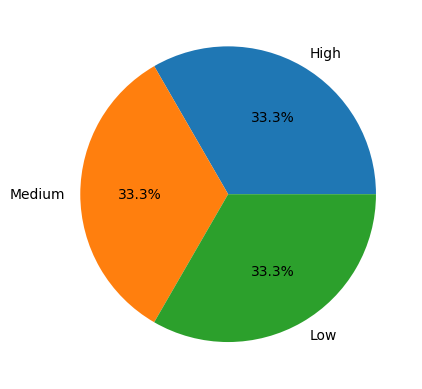

In [22]:
plt.pie(
    x=data_balanced["Addiction"].value_counts(),
    labels=data_balanced["Addiction"].value_counts().index,
    autopct='%0.1f%%'
)


In [23]:
X= data_balanced.drop('Addiction', axis=1)
Y= data_balanced['Addiction']

print(f'el tamaño de X es: {X.shape} \n'
      f'el tamaño de Y es: {Y.shape} \n')



el tamaño de X es: (7662, 24) 
el tamaño de Y es: (7662,) 



Aca los datos deben estar "limpios"

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_cols = X.select_dtypes(include=['object']).columns.to_list()

# Pipelines para cada tipo de dato
num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='passthrough')


In [25]:
X_pre=preprocessor.fit_transform(X)

cod_cat=preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)

labels = np.concatenate([num_cols, cod_cat])

X_pro=pd.DataFrame(X_pre, columns=labels)

X_pro.drop(['ordinalencoder__Gender',
            'ordinalencoder__School_Grade',
            'ordinalencoder__Phone_Usage_Purpose'
            ,'ordinalencoder__Addiction'], axis=1, inplace=True)

X_pro.head(10)    

,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,...,School_Grade_11th,School_Grade_12th,School_Grade_7th,School_Grade_8th,School_Grade_9th,Phone_Usage_Purpose_Browsing,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,0.333333,0.428571,0.56,0.5,0.00,1.000000,0.222222,0.777778,0.0,0.333333,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.500000,0.428571,0.40,0.5,0.00,0.222222,0.666667,0.222222,0.0,0.333333,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.500000,0.428571,0.86,0.8,0.25,0.111111,0.222222,1.000000,1.0,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.250000,0.142857,0.56,0.8,0.50,0.888889,1.000000,0.222222,0.0,0.333333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.166667,0.571429,0.12,0.4,0.25,0.000000,0.444444,0.000000,0.0,0.333333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5,0.333333,0.428571,0.78,0.3,0.25,0.555556,0.000000,0.222222,0.0,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.500000,0.571429,0.78,0.3,0.25,0.555556,0.666667,0.888889,0.0,0.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.416667,0.428571,0.40,0.2,0.50,0.444444,0.555556,0.777778,0.0,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,0.250000,0.857143,0.58,0.0,0.50,0.000000,0.666667,0.555556,0.0,0.333333,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
9,0.333333,0.428571,0.78,0.8,0.25,0.888889,0.000000,0.888889,0.0,0.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_pro, Y, test_size=0.7, random_state=123)   

print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {Y_train.shape} \n'
      f'El tamaño del conjunto de prueba es: {X_test.shape} {Y_test.shape} \n') 


El tamaño del conjunto de entrenamiento es: (2298, 31) (2298,) 
El tamaño del conjunto de prueba es: (5364, 31) (5364,) 



([<matplotlib.patches.Wedge at 0x1da31234320>,
 [Text(0.5316676150730835, 0.9629795154012881, 'High'),
  Text(-1.0993576018522295, -0.03758807323759569, 'Medium'),
  Text(0.5642632667853578, -0.9442494192514584, 'Low')],
 [Text(0.29000051731259097, 0.525261553855248, '33.9%'),
  Text(-0.599649601010307, -0.020502585402324924, '33.2%'),
  Text(0.30777996370110416, -0.5150451377735227, '32.9%')])

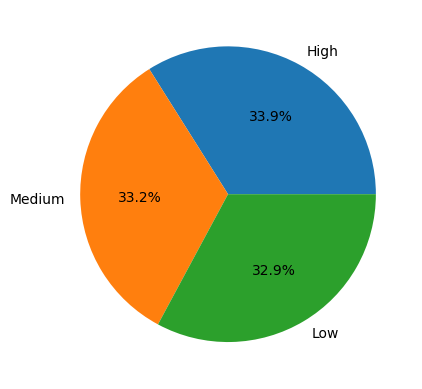

In [27]:
plt.pie(x=Y_train.value_counts(),
        labels=Y_train.value_counts().index,
        autopct='%0.1f%%')



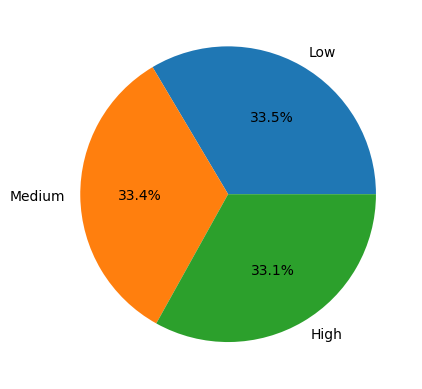

In [28]:
plt.pie(
    x=Y_test.value_counts(),
    labels=Y_test.value_counts().index,
    autopct='%0.1f%%'
)
plt.show()


REGRESIÓN LOGÍSTICA (el first)
kNN
maquina soporte vetotial
arboles decision
bosque aleatorio
adaptativa boosting
gradient boosting
RNA

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
modelo_1 = LogisticRegression(solver='saga', random_state=123)
param_grid={'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

clf_1= GridSearchCV(estimator=modelo_1,
                   param_grid=param_grid, cv=5, scoring='accuracy')


clf_1.fit(X_train, Y_train)




,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [30]:
validation = pd.concat([
    pd.DataFrame(clf_1.cv_results_['params']),
    pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns=['accuracy'])
], axis=1)

validation = validation.sort_values(by='accuracy', ascending=False)



validation

,C,penalty,accuracy
12,10.000,l1,0.916008
19,1000.000,l2,0.915574
15,100.000,l1,0.915574
18,1000.000,l1,0.915574
13,10.000,l2,0.913400
16,100.000,l2,0.912963
9,1.000,l1,0.911230
10,1.000,l2,0.896415
6,0.100,l1,0.891200
7,0.100,l2,0.838980


In [31]:
modelo_1_final = clf_1.best_estimator_
modelo_1_final


,penalty,'l1'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

        High       0.98      0.94      0.96       780
         Low       0.92      0.93      0.93       755
      Medium       0.88      0.90      0.89       763

    accuracy                           0.93      2298
   macro avg       0.93      0.93      0.93      2298
weighted avg       0.93      0.93      0.93      2298



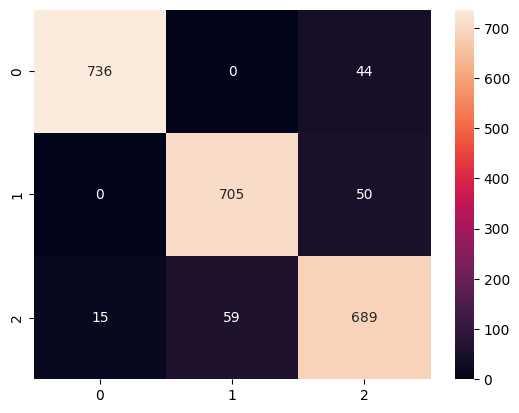

In [32]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_1_train = modelo_1_final.predict(X_train)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_train, y_pred_1_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_1_train), annot=True, fmt='d')

plt.show()

metricas de desempeño en validacion
              precision    recall  f1-score   support

        High       0.97      0.93      0.95      1774
         Low       0.90      0.91      0.91      1799
      Medium       0.85      0.87      0.86      1791

    accuracy                           0.91      5364
   macro avg       0.91      0.91      0.91      5364
weighted avg       0.91      0.91      0.91      5364



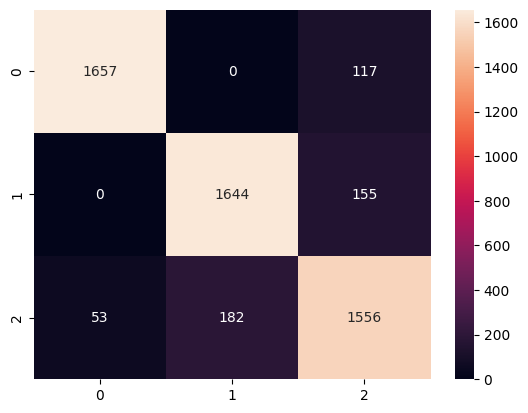

In [33]:
y_pred_test_1 = modelo_1_final.predict(X_test)
print("metricas de desempeño en validacion")

print(classification_report(Y_test, y_pred_test_1))
sb.heatmap(confusion_matrix(Y_test, y_pred_test_1), annot=True, fmt='d')

plt.show()


In [34]:
from sklearn.neighbors import KNeighborsClassifier
modelo_2 = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 19,21,53],'p': [1, 2]
}

clf_2=GridSearchCV(estimator=modelo_2,
                   param_grid=param_grid, cv=5, scoring='f1_weighted')


clf_2.fit(X_train, Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [35]:
validation = pd.concat([
    pd.DataFrame(clf_2.cv_results_['params']),
    pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns=['f1'])
], axis=1)

validation = validation.sort_values(by='f1', ascending=False)



validation

,n_neighbors,p,f1
0,3,1,0.783262
1,3,2,0.769427
2,5,1,0.765569
4,7,1,0.758171
3,5,2,0.733423
5,7,2,0.715398
6,19,1,0.678853
8,21,1,0.656762
7,19,2,0.636390
9,21,2,0.629547


In [36]:
modelo_2_final = clf_2.best_estimator_
modelo_2_final

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

        High       0.94      0.80      0.86       780
         Low       0.97      1.00      0.98       755
      Medium       0.84      0.94      0.89       763

    accuracy                           0.91      2298
   macro avg       0.92      0.91      0.91      2298
weighted avg       0.92      0.91      0.91      2298



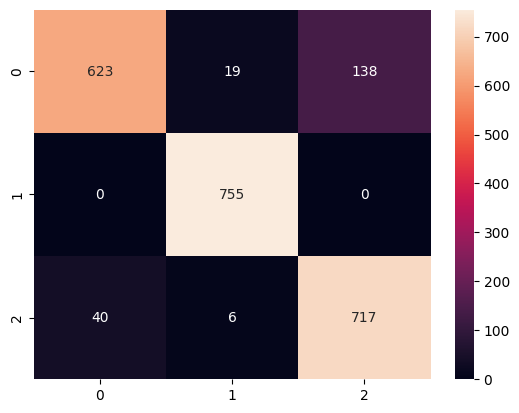

In [37]:
y_pred_2_train = modelo_2_final.predict(X_train)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_train, y_pred_2_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_2_train), annot=True, fmt='d')

plt.show()

metricas de desempeño en validacion
              precision    recall  f1-score   support

        High       0.77      0.61      0.68      1774
         Low       0.95      1.00      0.97      1799
      Medium       0.69      0.80      0.74      1791

    accuracy                           0.80      5364
   macro avg       0.80      0.80      0.80      5364
weighted avg       0.80      0.80      0.80      5364



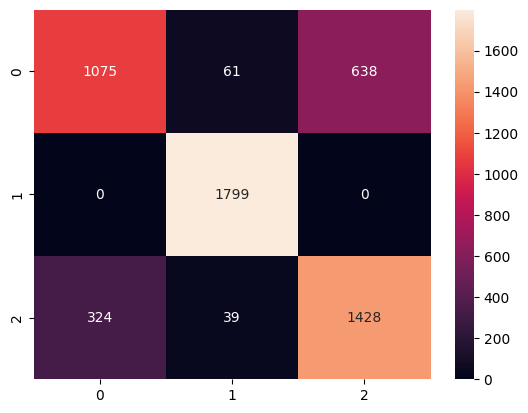

In [38]:
y_pred_test_2= modelo_2_final.predict(X_test)
print("metricas de desempeño en validacion")

print(classification_report(Y_test, y_pred_test_2))
sb.heatmap(confusion_matrix(Y_test, y_pred_test_2), annot=True, fmt='d')

plt.show()


Maquina de soporte vectorial

In [ ]:
from sklearn.svm import SVC

modelo_3 = SVC(random_state=123)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'degree': [2, 3, 4]}

clf_3 = GridSearchCV(estimator=modelo_3,
                    param_grid=param_grid, cv=5, scoring='f1_weighted')

clf_3.fit(X_train, Y_train)

#preguntar, cuantos modelos se generaron

In [ ]:
validation = pd.concat([
    pd.DataFrame(clf_3.cv_results_['params']),
    pd.DataFrame(clf_3.cv_results_['mean_test_score'], columns=['f1'])
], axis=1)

validation = validation.sort_values(by='f1', ascending=False)

validation

,C,degree,kernel,f1
41,1.000,3,poly,0.967771
78,1000.000,3,rbf,0.967337
74,1000.000,2,rbf,0.967337
82,1000.000,4,rbf,0.967337
66,100.000,3,rbf,0.967337
...,...,...,...,...
4,0.001,3,linear,0.172029
0,0.001,2,linear,0.172029
1,0.001,2,poly,0.172029
22,0.010,4,rbf,0.172029


TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
modelo_4 = DecisionTreeClassifier(random_state=123)

param_grid = {'criterion': ['log_loss', 'gini', 'entropy'],
              'max_depth': [None, 5, 10, 15, 20], 
              'max_leaf_nodes': [None, 10,20,50],
              'min_samples_split': [2, 3, 4]}

clf_4 = GridSearchCV(estimator=modelo_4,
                    param_grid=param_grid, cv=5, scoring='f1_weighted')

clf_4.fit(X_train, Y_train)




,estimator,DecisionTreeC...dom_state=123)
,param_grid,"{'criterion': ['log_loss', 'gini', ...], 'max_depth': [None, 5, ...], 'max_leaf_nodes': [None, 10, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'log_loss'


In [ ]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'], columns=['f1'])], axis=1)
validation = validation.sort_values(by='f1', ascending=False)

validation

,criterion,max_depth,max_leaf_nodes,min_samples_split,f1
2,log_loss,NaN,NaN,4,0.926599
50,log_loss,20.0,NaN,4,0.926599
38,log_loss,15.0,NaN,4,0.926599
158,entropy,15.0,NaN,4,0.926599
170,entropy,20.0,NaN,4,0.926599
...,...,...,...,...,...
149,entropy,10.0,10.0,4,0.757398
173,entropy,20.0,10.0,4,0.757398
76,gini,5.0,10.0,3,0.755958
77,gini,5.0,10.0,4,0.755958


profundidad del arbol: 12
número de nodos hoja: 150


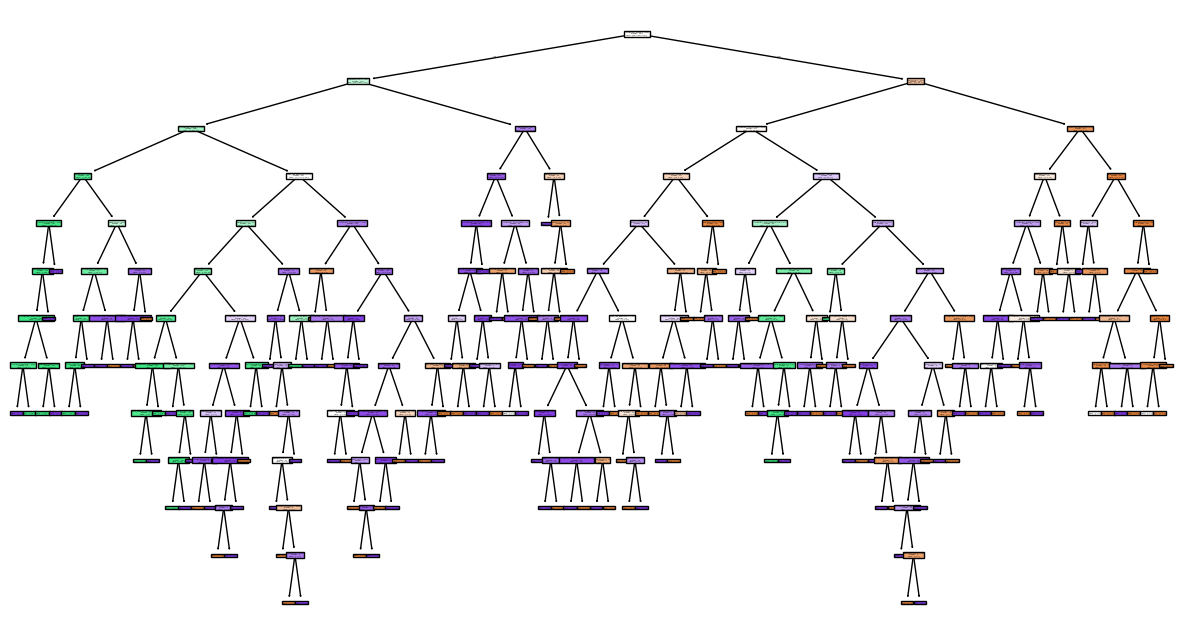

In [ ]:


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

modelo_4_final = clf_4.best_estimator_

fig, ax = plt.subplots(figsize=(15, 8))

print(f'profundidad del arbol: {modelo_4_final.get_depth()}')
print(f'número de nodos hoja: {modelo_4_final.get_n_leaves()}')

plot_tree(modelo_4_final, feature_names=labels, filled=True, impurity=False, ax=ax)
plt.show()

metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

        High       0.96      0.87      0.91      1774
         Low       0.98      1.00      0.99      1799
      Medium       0.89      0.95      0.92      1791

    accuracy                           0.94      5364
   macro avg       0.94      0.94      0.94      5364
weighted avg       0.94      0.94      0.94      5364



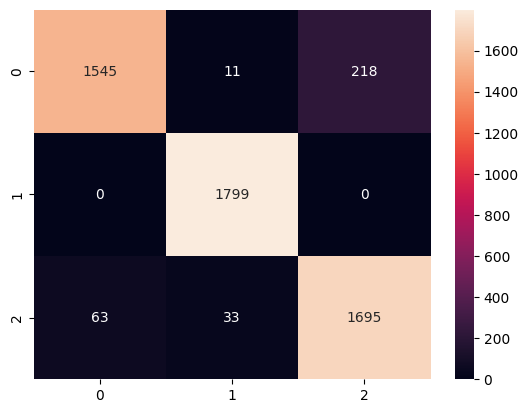

In [ ]:
y_pred_4_test = modelo_4_final.predict(X_test)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_test, y_pred_4_test))
sb.heatmap(confusion_matrix(Y_test, y_pred_4_test), annot=True, fmt='d')

plt.show()

metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

        High       0.99      1.00      1.00       780
         Low       1.00      1.00      1.00       755
      Medium       1.00      0.99      1.00       763

    accuracy                           1.00      2298
   macro avg       1.00      1.00      1.00      2298
weighted avg       1.00      1.00      1.00      2298



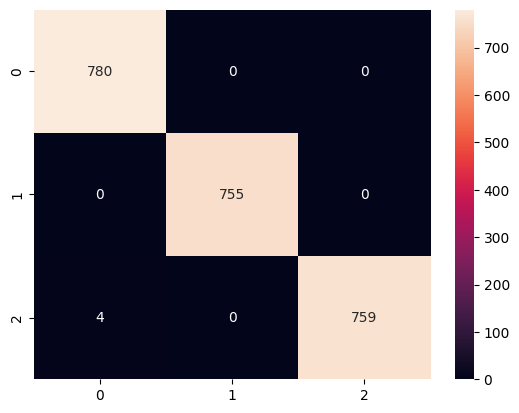

In [ ]:
y_pred_4_train = modelo_4_final.predict(X_train)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_train, y_pred_4_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_4_train), annot=True, fmt='d')

plt.show()

In [ ]:
#hasta aca la tarea